In [98]:
from angle_emb import AnglE, Prompts
from angle_emb.utils import cosine_similarity
import pandas as pd
import numpy as np
from tqdm import tqdm_notebook as tqdm
import matplotlib.pyplot as plt
import matplotlib
import json
import os
import tiktoken
from openai import OpenAI
import warnings
import networkx as nx
from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

In [2]:
tokenizer = tiktoken.encoding_for_model("gpt-4") 

In [ ]:
comments = pd.read_csv('./data/comments_climate_change.csv')
submissions = pd.read_csv('./data/submissions_climate_change.csv')

In [ ]:
def normalize_l2(x):
    x = np.array(x)
    if x.ndim == 1:
        norm = np.linalg.norm(x)
        if norm == 0:
            return x
        return x / norm
    else:
        norm = np.linalg.norm(x, 2, axis=1, keepdims=True)
        return np.where(norm == 0, x, x / norm)

In [5]:
def get_batches():
    batch_list_df = pd.DataFrame()
    for i in client.batches.list():
        temp_batch_df = pd.DataFrame([dict(i)])
        batch_list_df = pd.concat([batch_list_df, temp_batch_df])
    return batch_list_df

In [ ]:
def retrieve_results(files):
    response_df = pd.DataFrame()
    for file in files:
        file_response = client.files.content(file)
        content = file_response.content.decode("utf-8")
        json_objects = content.splitlines()
        parsed_objects = [json.loads(obj) for obj in json_objects]
        responses = pd.DataFrame(parsed_objects)
        responses['file'] = file
        response_df = pd.concat([response_df, responses])

    return response_df 

In [6]:
submissions['selftext'] = submissions['selftext'].astype(str)
submissions['selftext'] = submissions['selftext'].apply(lambda x: x.replace('\n', ' '))
submissions.loc[submissions['selftext'] == 'nan', 'selftext'] = ''
submissions.loc[submissions['selftext'] == '[removed]', 'selftext'] = ''
submissions.loc[submissions['selftext'] == '[deleted]', 'selftext'] = ''
submissions['title'] = submissions['title'].astype(str)
submissions['title'] = submissions['title'].apply(lambda x: x.replace('\n', ' '))
submissions['scoring_text'] = submissions.apply(lambda x: x['title'] + ' ' + x['selftext'], axis=1)
submissions = submissions.loc[submissions['author'] != 'u/[deleted]']

In [7]:
comments['body'] = comments['body'].astype(str)
comments.loc[comments['body'] == 'nan', 'body'] = ''
comments.loc[comments['body'] == '[removed]', 'body'] = ''
comments.loc[comments['body'] == '[deleted]', 'body'] = ''
comments['scoring_text'] = comments['body'].apply(lambda x: x.replace('\n', ' '))
comments = comments.loc[comments['author'] != 'u/[deleted]']

In [8]:
convert_to_embedding_jsonl(df=comments, subreddit='climatechange', file_format='_547_comments_part', FILE_PATH='JSONL/')
files = [x for x in os.listdir('./JSONL/') if '.jsonl' in x]
create_files(file_list=files, file_path='./JSONL/')
file_list_df = get_files()

In [ ]:
for filename in file_list_df.loc[file_list_df['filename'].str.contains('climatechange')]['id']:
    batch_id = client.batches.create(
        input_file_id=filename,
        endpoint="/v1/embeddings",
        completion_window="24h",
        metadata={"batch_description": "ClimateChange547"}
    )

In [9]:
batch_list_df = get_batches()

INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches?after=batch_67fa7b4e544c819093443af845f5c10e "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches?after=batch_67fa7b4a81708190a2cf41823bce83f7 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches?after=batch_67fa7b458a1c8190acd4a9f307e919dc "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches?after=batch_67fa7b4167d08190b687cc0a10c19e59 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches?after=batch_67fa7b3d377081908a0da60f65d6bfe7 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches?after=batch_67fa7b3923988190a5fd49f47fa87c67 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/batches?after=batch_67fa7b350adc8190be3ba8cc55ff39cd "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://

In [11]:
embedding_df = retrieve_results(batch_list_df.loc[batch_list_df['metadata'].apply(lambda x: isinstance(x, dict) and 'batch_description' in x and x['batch_description'] == 'ClimateChange547')]['output_file_id'])

INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-1axm7bVcC5RFnWxmnVbVqr/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-AycHDSLapijZsemJPZLw8d/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-KTzpPTtkxMCjCeZNBhKdJb/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-7aaY9rakqf8h8JaG6JB3im/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-KVH1y6gELbPp7HzWSAh2w8/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-HbNsS5Zr4ubUR28BeBPu7Z/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-5BrXnEb8AECWPuEVFc3NDG/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-BAoncR6gEesJAiSthEpUP9/content "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.openai.com/v1/files/file-UeqdLYtweMsQjL

In [12]:
embedding_df['embedding'] = embedding_df['response'].apply(lambda x: x['body']['data'][0]['embedding'])

In [14]:
doc_vecs = np.vstack(embedding_df['embedding'])
doc_vecs_128 = doc_vecs[:, :128]
normalized_vecs = normalize_l2(doc_vecs_128)
expanded_vector_df = pd.DataFrame(normalized_vecs)

In [15]:
expanded_vector_df.head()

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,-0.136540,0.062951,-0.092461,0.034690,0.033626,0.032493,0.054810,-0.003648,-0.049352,0.129510,...,0.092183,0.242553,0.020976,0.030759,0.101480,0.161795,-0.058603,0.084366,-0.094126,-0.260129
1,0.002132,-0.122776,-0.074979,0.034130,-0.044666,0.010129,-0.097426,-0.033443,-0.041460,-0.119620,...,0.040493,0.269780,0.108523,-0.009767,0.154844,0.038813,-0.012420,-0.060981,-0.035580,-0.085363
2,-0.051721,0.093902,-0.083237,-0.048372,-0.009688,0.064638,-0.013151,0.228110,-0.067425,0.138817,...,0.007912,-0.109660,-0.124024,0.068926,0.021841,0.118557,-0.174191,0.030550,-0.049068,0.000382
3,-0.030449,0.035878,-0.088257,-0.064070,0.010165,-0.018033,-0.027493,0.107231,0.047488,0.023166,...,0.055093,0.171462,-0.099975,0.140609,0.191027,0.097018,0.066220,0.012396,0.009406,-0.218976
4,0.017043,-0.048606,-0.057684,0.120744,0.003999,-0.063545,0.037699,-0.022056,-0.151503,0.035672,...,0.056582,0.180852,-0.015368,-0.034747,-0.020998,-0.022540,0.026308,-0.204472,-0.052925,-0.152825


In [16]:
expanded_vector_df = expanded_vector_df.reset_index(drop=True)
embedding_df = embedding_df.reset_index(drop=True)

In [17]:
embedding_df_final = pd.concat([embedding_df, expanded_vector_df], axis=1)
embedding_df_final = embedding_df_final.drop(columns=['embedding', 'id'])
embedding_df_final = embedding_df_final.rename(columns={'custom_id': 'id'})

In [18]:
submissions_final = submissions.merge(embedding_df_final, on='id', how='left')
comments_final = comments.merge(embedding_df_final, on='id', how='left')

In [19]:
submissions_final['month_year'] = pd.to_datetime(submissions_final['created']).dt.to_period("M")
comments_final['month_year'] = pd.to_datetime(comments_final['created']).dt.to_period("M")

In [20]:
comments_final = comments_final.loc[comments_final['body'] != '']

In [21]:
all_content = pd.concat([submissions_final, comments_final])
final_all_content = all_content.loc[all_content['author'].isin(selected_authors['author'])]

In [22]:
group_all_content = all_content.groupby(['author', 'month_year'])[expanded_vector_df.columns].mean().reset_index()
# grouped_submissions = submissions_final.groupby(['author', 'month_year'])[expanded_vector_df.columns].mean().reset_index()

In [23]:
filter_authors = group_all_content['author'].value_counts().reset_index()

In [24]:
selected_authors = filter_authors.loc[filter_authors['count'] >= 6]

In [25]:
subset_grouped_content = group_all_content.loc[group_all_content['author'].isin(selected_authors['author'])]
subset_grouped_content['id'] = pd.factorize(subset_grouped_content['author'])[0] + 1
subset_grouped_content = subset_grouped_content.loc[subset_grouped_content['month_year'] != '2022-12']
subset_grouped_content.to_csv('./final_embedding_data.csv', index=False)

### k-means for a single month year

In [466]:
final_all_content.loc[(final_all_content['author'].isin(group1.loc[group1['Cluster'] == 0]['author'])) & (final_all_content['month_year'] == '2023-07')]['scoring_text'].sum()

'Mapped: How climate change affects extreme weather around the world Hello. Is r/collapse right in that there\'s literally nothing we can do and having hope is pointless? interesting perspective about Co2 An surprising accidental benefit. An surprising accidental benefit Far from being pollution, all modern life on earth depends on an invisible gas that almost got down to catastrophic levels. Humans inadvertently saved the planet, and the guy who helped save the world from unchecked nuclear testing explains how. How fight Climate Change according to r/Co*****e Taken from a thread on everyone’s favourite sub:  I wonder how long they\'re going to keep this going. It\'s pretty clear by now humanity has no real desire of its own to stop this transformation. Every election makes that clear: People want this. They\'re voting for this. They\'re voting for the annihilation of all non-human life.  Yep.  Not only are we voting for this at the polls, we\'re also voting for it with our wallets.  A

In [485]:
group1['id'].nunique()

165

In [520]:
group1 = subset_grouped_content.loc[subset_grouped_content['month_year'] == '2023-06']
inertia = []
k_values = range(1, 15)
X = group1[expanded_vector_df.columns]
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, init="k-means++",)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

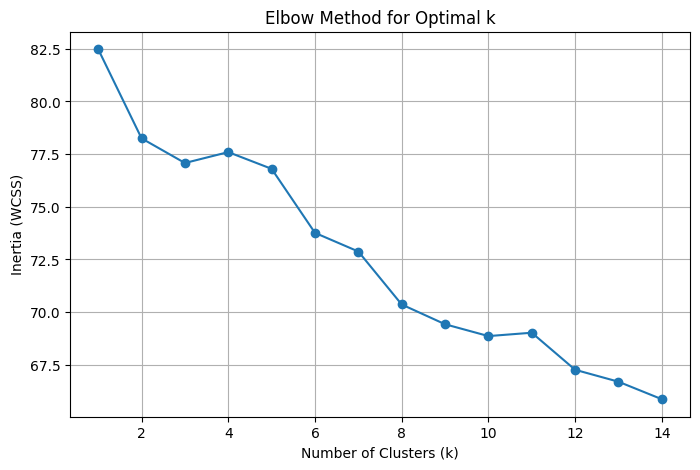

In [521]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [522]:
kmeans = KMeans(n_clusters=3, random_state=42, init="k-means++",)
kmeans.fit(X)
# labels = 
group1["Cluster"] = kmeans.labels_ 

In [523]:
group1["Cluster"].value_counts()

Cluster
1    171
0     43
2      3
Name: count, dtype: int64

In [499]:
group1.shape[0] / 2

85.0

### For Visualization TSNE

In [ ]:
# 0 - red
# 1 - purple
# 2 - blue

In [280]:
group1["Cluster"] = model.labels_ 

In [223]:
tsne = TSNE(n_components=3, perplexity=15, random_state=42, init="random", learning_rate=200)
tsne.fit(X)

TSNE(init='random', learning_rate=200, n_components=3, perplexity=15,
     random_state=42)

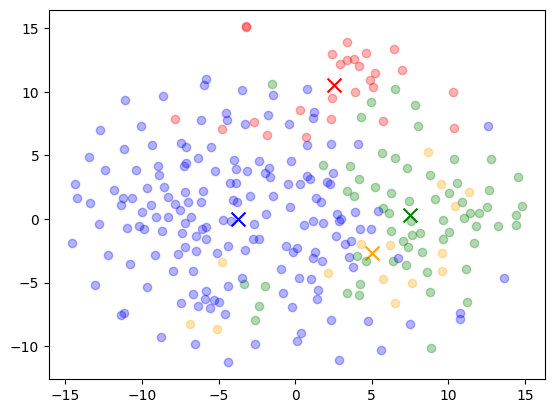

In [ ]:

x = [x for x, y in vis_dims2]
y = [y for x, y in vis_dims2]

for category, color in enumerate(["orange", "green", "red", "blue"]):
    xs = np.array(x)[group1.Cluster == category ]
    ys = np.array(y)[group1.Cluster == category ]
    plt.scatter(xs, ys, color=color, alpha=0.3)

    avg_x = xs.mean()
    avg_y = ys.mean()

    plt.scatter(avg_x, avg_y, marker="x", color=color, s=100)
# plt.title("Clusters identified visualized in language 2d using t-SNE")

In [524]:
submissions = submissions.rename(columns={'id': 'post_id'})
comments = comments.rename(columns={'author': 'comment_author'})
submissions['month_year'] =  pd.to_datetime(submissions['created']).dt.to_period("M")
full_merge = submissions.merge(comments, left_on='name', right_on='parent_id', how='left')[['post_id', 'author', 'comment_author', 'month_year']]
one_month = full_merge.loc[full_merge['month_year'] == '2023-06']
users_to_keep = list(selected_authors['author'])
result = one_month.groupby('post_id').apply(lambda x: set(set(x['author'].dropna().tolist() + x['comment_author'].dropna().tolist()) & set(users_to_keep))).reset_index(name='unique_users')
result = result[result['unique_users'].map(len) > 0]

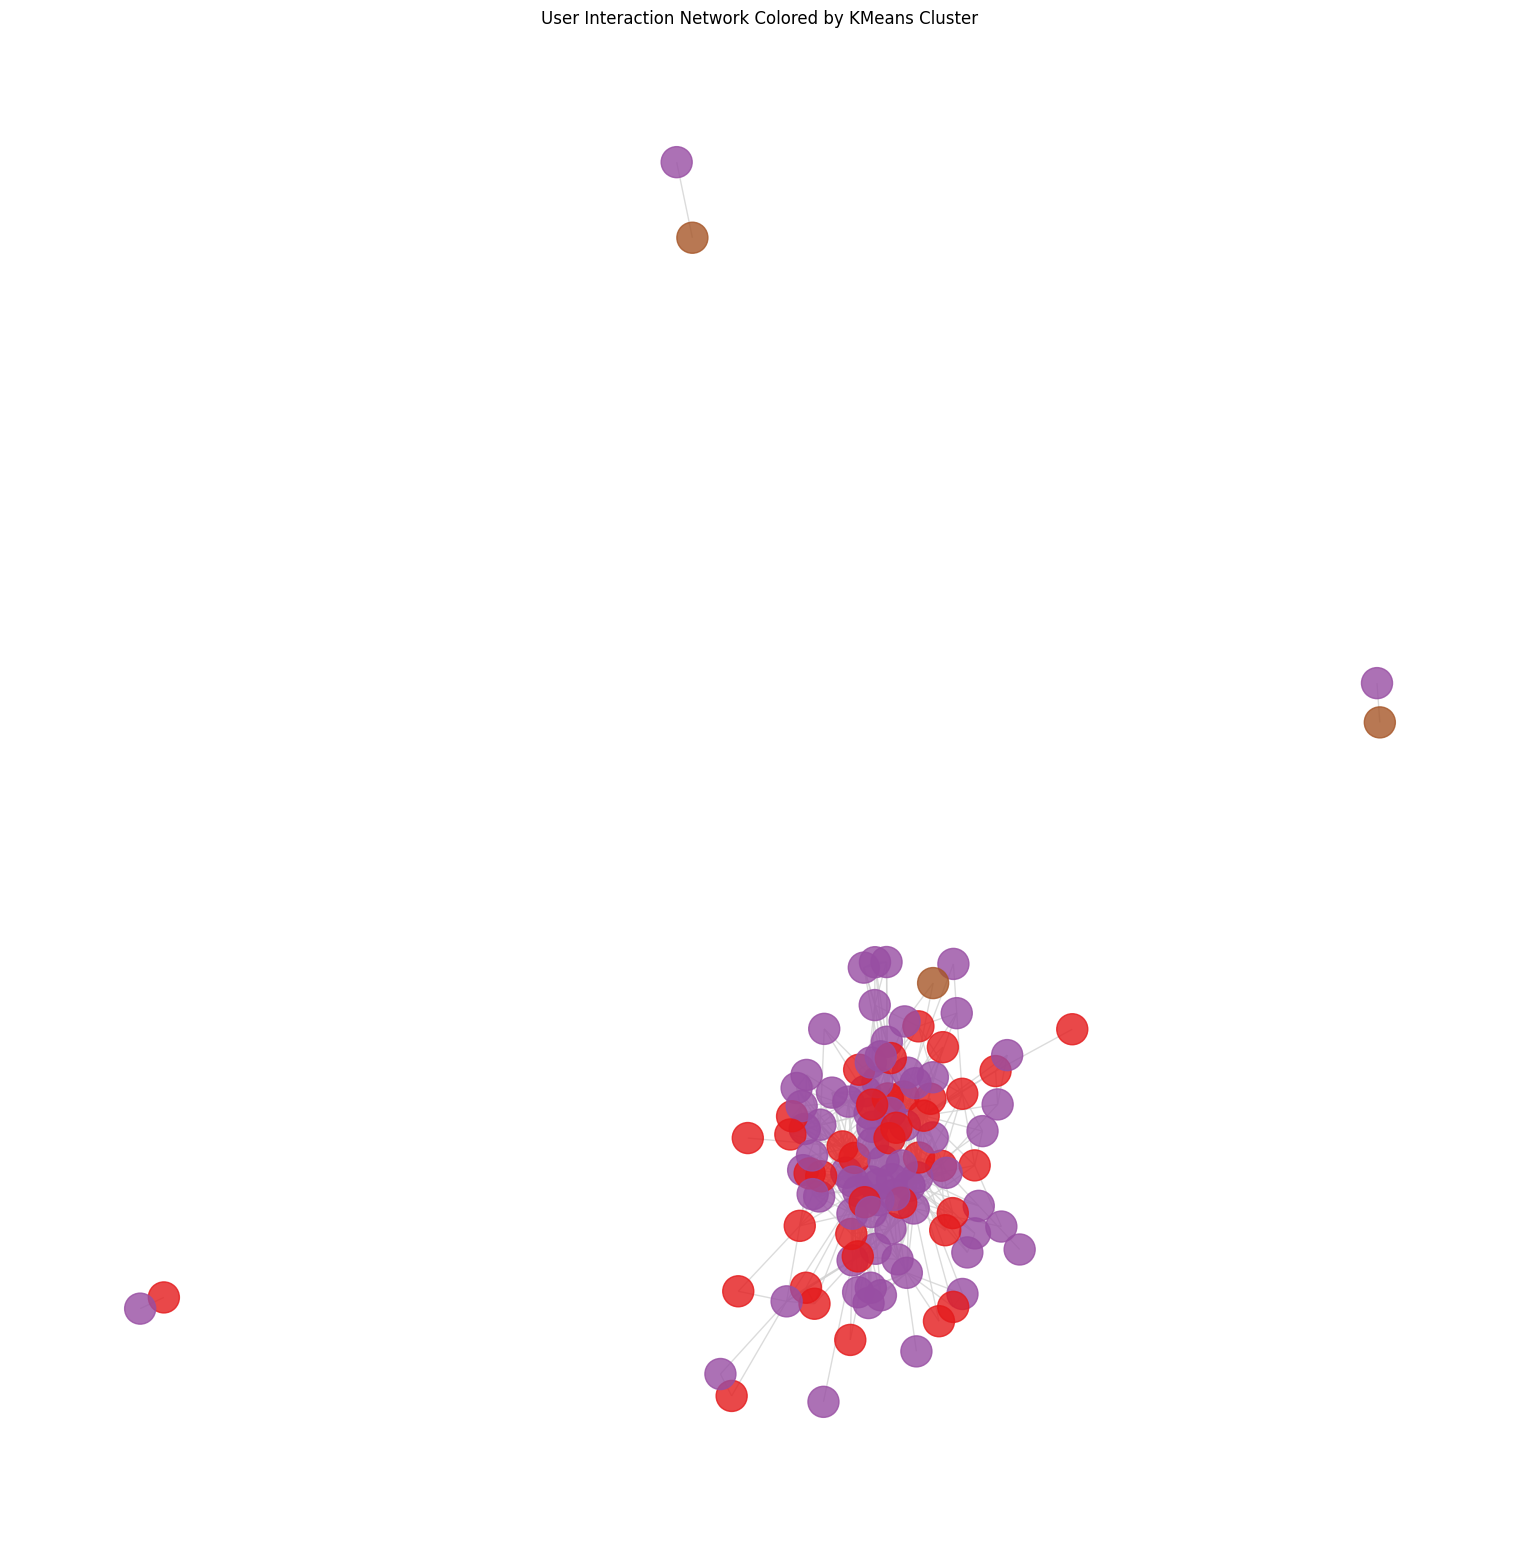

In [502]:
user_clusters = group1[['author', 'Cluster']]

# Step 2: Build your user interaction network
G = nx.Graph()

for users in result['unique_users']:
    user_list = list(users)
    if len(user_list) > 1:
        edges = combinations(user_list, 2)
        G.add_edges_from(edges)

# Step 3: Set cluster as node attribute
user_cluster_dict = dict(zip(user_clusters['author'], user_clusters['Cluster']))
nx.set_node_attributes(G, user_cluster_dict, name='Cluster')

# Step 4: Assign colors based on cluster
unique_clusters = list(set(kmeans.labels_))
color_map = {cluster: plt.cm.Set1(i / len(unique_clusters)) for i, cluster in enumerate(unique_clusters)}

# Some users might not have a cluster (e.g. not in the KMeans data)
node_colors = [color_map.get(G.nodes[n].get('Cluster'), 'gray') for n in G.nodes()]

# Step 5: Draw graph
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G, pos,
    with_labels=False,
    node_color=node_colors,
    edge_color='lightgray',
    node_size=500,
    alpha=0.8
)

plt.title("User Interaction Network Colored by KMeans Cluster")
plt.show()

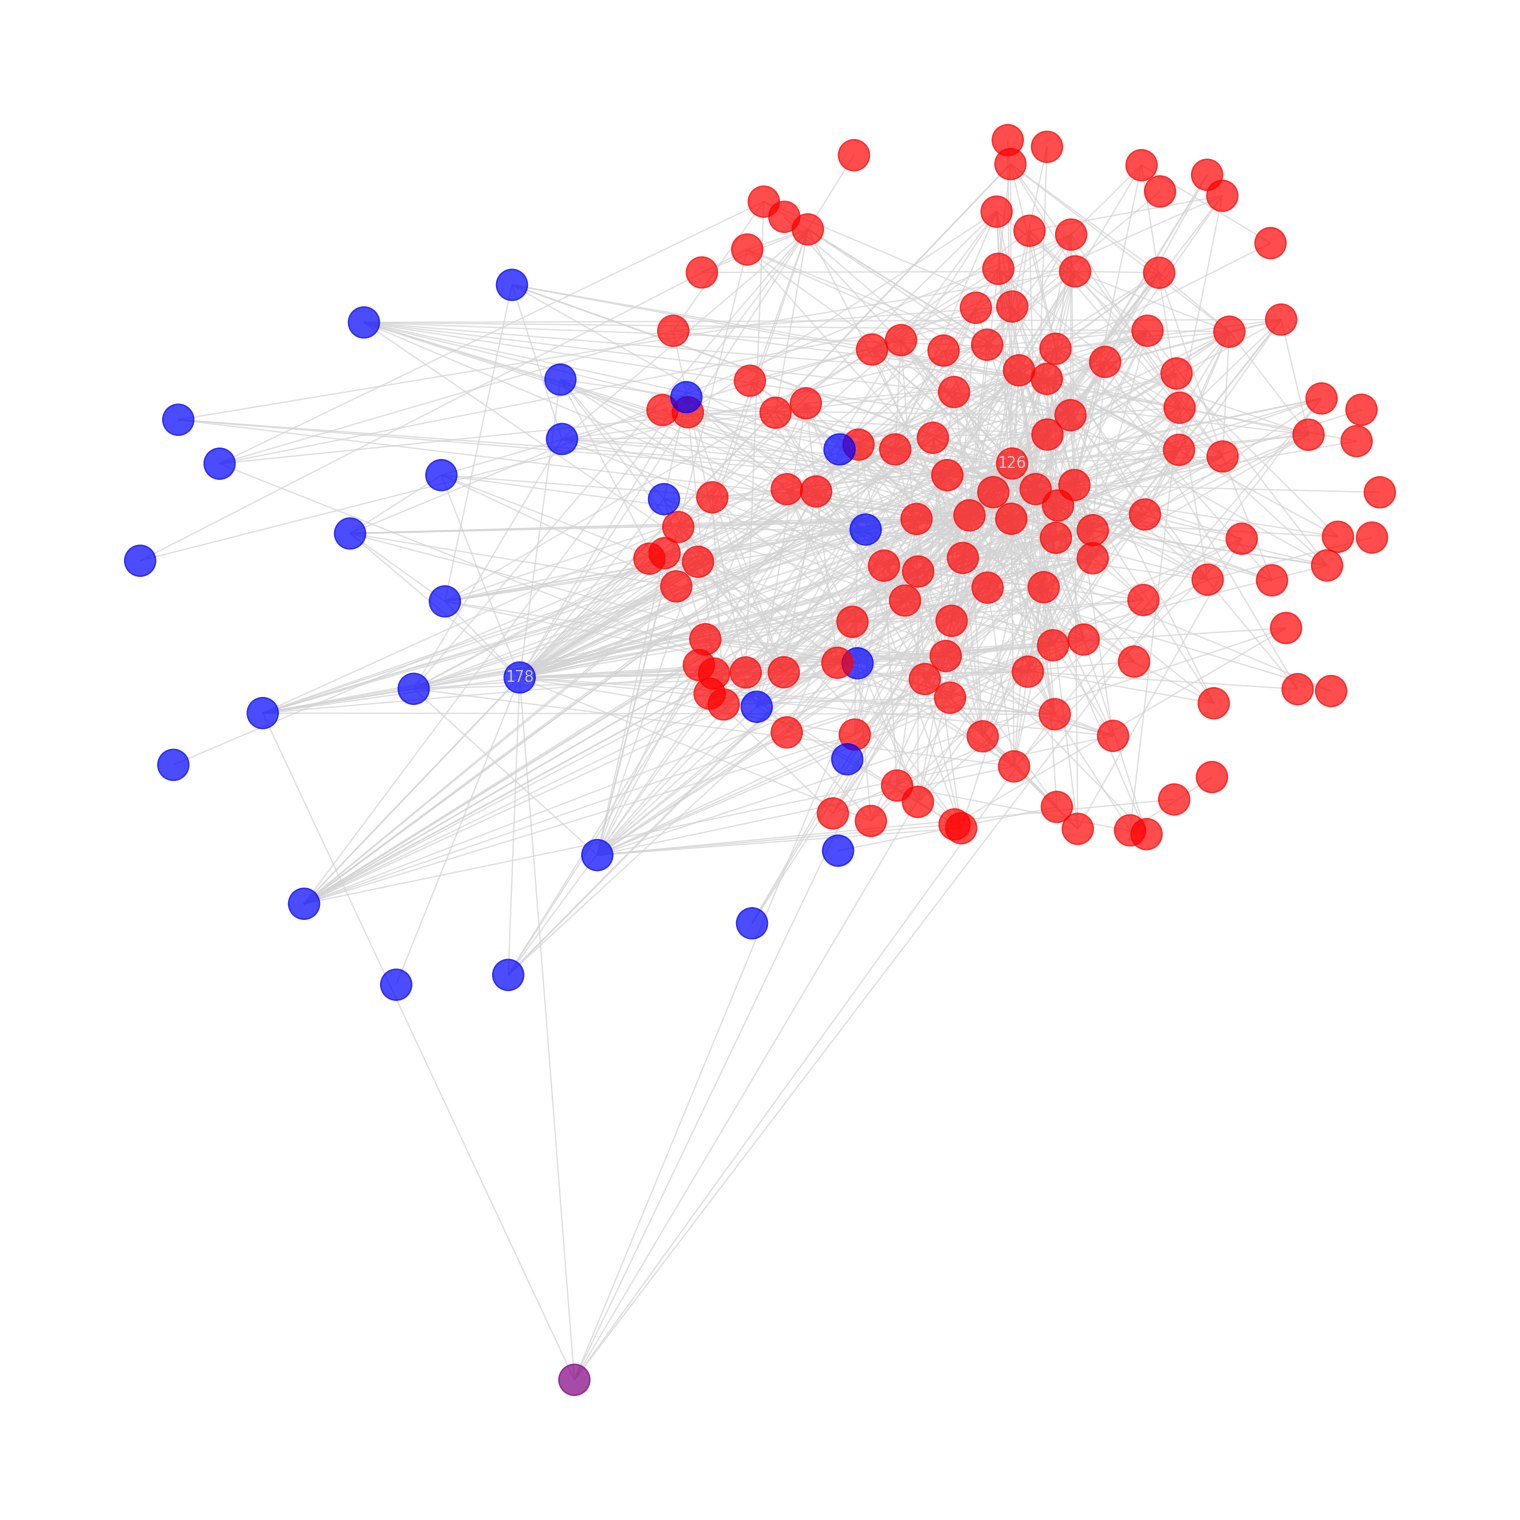

In [525]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations

user_clusters = group1[['author', 'Cluster']]
color_map = {
    1: 'red',
    2: 'purple',
    0: 'blue'
}
# Step 2: Build the user interaction network
G = nx.Graph()

for users in result['unique_users']:
    user_list = list(users)
    if len(user_list) > 1:
        edges = combinations(user_list, 2)
        G.add_edges_from(edges)

# Step 3: Set cluster as node attribute
user_cluster_dict = dict(zip(user_clusters['author'], user_clusters['Cluster']))
nx.set_node_attributes(G, user_cluster_dict, name='Cluster')

# Step 4: Assign colors based on cluster
unique_clusters = sorted(set(kmeans.labels_))
# color_map = {cluster: plt.cm.Set1(i / len(unique_clusters)) for i, cluster in enumerate(unique_clusters)}
node_colors = [color_map.get(G.nodes[n].get('Cluster'), 'purple') for n in G.nodes()]

# === NEW Step 5: Position nodes by cluster group ===
clusters = nx.get_node_attributes(G, 'Cluster')
cluster_positions = {c: np.random.rand(2) * 3 for c in unique_clusters}  # tighter centroids

# Calculate spring layout within each cluster, with low k for tight spacing
pos = {}
for cluster in unique_clusters:
    cluster_nodes = [n for n, attr in clusters.items() if attr == cluster]
    subG = G.subgraph(cluster_nodes)
    # Lower `k` means nodes are closer, try tuning 0.1–0.3
    sub_pos = nx.spring_layout(subG, seed=42, k=1, scale=1)

    offset = cluster_positions[cluster]
    for node, coords in sub_pos.items():
        pos[node] = coords + offset

# Fallback for unclustered nodes
for node in G.nodes():
    if node not in pos:
        pos[node] = np.random.rand(2) * 3

author_to_id = dict(zip(group1['author'], group1['id']))

nodes_to_label = [n for n in G.nodes() if G.degree(n) > 50]
labels = {node: author_to_id.get(node, "") for node in nodes_to_label}
# Step 6: Draw the graph
plt.figure(figsize=(15, 15))
nx.draw(
    G, pos,
    labels=labels,
    node_color=node_colors,
    edge_color='lightgray',
    node_size=500,
    alpha=0.7,
    font_size=11,
    font_color='white'
    
)

# nx.draw_networkx_labels(G, pos, labels=labels, font_size=12, font_color='black')
plt.savefig("user_network202301.png", format='png', dpi=300, bbox_inches='tight')
# plt.title("User Interaction Network Grouped by KMeans Cluster", fontsize=16)
plt.show()

#### AnglE Model

In [ ]:
angle = AnglE.from_pretrained('WhereIsAI/UAE-Large-V1', pooling_strategy='cls').cuda()
texts = list(submissions['scoring_text'])  # full list or slice
batch_size = 8
all_vecs = []

for i in range(0, len(texts), batch_size):
    batch = texts[i:i + batch_size]
    batch_vecs = angle.encode(batch)
    all_vecs.append(batch_vecs)
doc_vecs = np.vstack(all_vecs)
embedding_df = pd.DataFrame(doc_vecs)
submissions_embed = pd.concat([submissions, embedding_df], axis=1)
submissions_embed.to_csv('./data/submissions_climate_change_embed.csv', index=False)

In [17]:
texts = list(comments['body'])  # full list or slice
batch_size = 8
all_vecs = []

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i + batch_size]
    batch_vecs = angle.encode(batch)
    all_vecs.append(batch_vecs)


#### Cluster Shifts

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans

months = ['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12']

# Collect clustering results
clustered_data = []

for month in months:
    group = subset_grouped_content.loc[subset_grouped_content['month_year'] == month].copy()
    X = group.drop(columns=['author', 'month_year'])

    kmeans = KMeans(n_clusters=3, random_state=42, init="k-means++")
    kmeans.fit(X)

    group['Cluster'] = kmeans.labels_
    group['month_year'] = month  # Ensure consistent format
    clustered_data.append(group[['author', 'month_year', 'Cluster']])

# Combine all months into one DataFrame
all_clustered_data = pd.concat(clustered_data, ignore_index=True)

# Pivot to create user_cluster_history
user_cluster_history = all_clustered_data.pivot_table(
    index='author',
    columns='month_year',
    values='Cluster',
    aggfunc='first'
).reset_index()

user_cluster_history.columns.name = None

In [ ]:
import plotly.graph_objects as go
import pandas as pd

def plot_sankey_with_missing(user_cluster_df, month_list):
    df_filled = user_cluster_df.copy()

    # Fill NaNs with string "Missing"
    df_filled[month_list] = df_filled[month_list].fillna("Inactive").astype(str)

    labels = []
    label_to_index = {}
    sources = []
    targets = []
    values = []

    # Create unique labels for each month-cluster pair
    for month in month_list:
        unique_values = sorted(df_filled[month].unique())
        for val in unique_values:
            label = f"{month} - C{val}"
            if label not in label_to_index:
                label_to_index[label] = len(labels)
                labels.append(label)

    # Create flows between consecutive months
    for i in range(len(month_list) - 1):
        month_from = month_list[i]
        month_to = month_list[i + 1]

        flow_counts = df_filled.groupby([month_from, month_to]).size().reset_index(name='count')

        for _, row in flow_counts.iterrows():
            src_label = f"{month_from} - C{row[month_from]}"
            tgt_label = f"{month_to} - C{row[month_to]}"
            sources.append(label_to_index[src_label])
            targets.append(label_to_index[tgt_label])
            values.append(row['count'])

    # Plot Sankey diagram
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=labels
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values
        ))])

    fig.update_layout(title_text="User Cluster Transitions Over Months", font_size=12)
    fig.show()

months_to_use = ['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12']
plot_sankey_with_missing(user_cluster_history, months_to_use)

#### Cluster Profiling using TF-IDF

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import re
import string

# Step 1: Merge cluster labels with all_content
group1_filtered = group1[['author', 'month_year', 'Cluster']]
group1_filtered['month_year'] = group1_filtered['month_year'].astype(str)  # Ensure matchable format

all_content['month_year'] = all_content['month_year'].astype(str)

merged = pd.merge(all_content, group1_filtered, on=['author', 'month_year'], how='inner')

# Step 2: Preprocess and combine text
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    return text

merged['combined_text'] = merged['title'].fillna('') + " " + merged['selftext'].fillna('') + " " + merged['text'].fillna('') + " " + merged['body'].fillna('')
merged['clean_text'] = merged['combined_text'].apply(clean_text)

# Step 3: Function to extract top key phrases for each cluster
def extract_top_phrases(df, cluster_col='Cluster', text_col='clean_text', top_n=5):
    top_phrases_per_cluster = {}

    for cluster in sorted(df[cluster_col].unique()):
        cluster_texts = df[df[cluster_col] == cluster][text_col].tolist()

        # TF-IDF Vectorizer for bi-grams and tri-grams
        vectorizer = TfidfVectorizer(ngram_range=(2, 3), max_features=1000, stop_words='english')
        tfidf_matrix = vectorizer.fit_transform(cluster_texts)

        # Sum scores for each phrase
        phrase_scores = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
        phrases = vectorizer.get_feature_names_out()

        top_indices = phrase_scores.argsort()[::-1][:top_n]
        top_phrases = [(phrases[i], phrase_scores[i]) for i in top_indices]
        top_phrases_per_cluster[cluster] = top_phrases

    return top_phrases_per_cluster

# Step 4: Run and view
top_phrases = extract_top_phrases(merged)

# Print out top phrases for each cluster
for cluster, phrases in top_phrases.items():
    print(f"\nCluster {cluster} Top Phrases:")
    for phrase, score in phrases:
        print(f"{phrase} (score: {score:.4f})")

#### Cluster Profiling using KeyBERT

In [ ]:
!pip install keybert
!pip install sentence-transformers

In [ ]:
from keybert import KeyBERT
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import re

# Step 1: Clean text
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r"[^\w\s]", "", text)
    return text

merged['combined_text'] = merged['title'].fillna('') + " " + \
                          merged['selftext'].fillna('') + " " + \
                          merged['text'].fillna('') + " " + \
                          merged['body'].fillna('')
merged['clean_text'] = merged['combined_text'].apply(clean_text)

# Step 2: Initialize KeyBERT model
kw_model = KeyBERT(model='paraphrase-MiniLM-L6-v2')  # You can use others too

# Step 3: Extract top key phrases per cluster
cluster_phrases = {}

for cluster in sorted(merged['Cluster'].unique()):
    cluster_df = merged[merged['Cluster'] == cluster]
    full_text = " ".join(cluster_df['clean_text'].tolist())

    keywords = kw_model.extract_keywords(
        full_text,
        keyphrase_ngram_range=(2, 3),
        stop_words='english',
        top_n=10,
        use_maxsum=True,
        nr_candidates=30
    )

    cluster_phrases[cluster] = keywords

# Step 4: Display
for cluster, phrases in cluster_phrases.items():
    print(f"\n🔹 Cluster {cluster} Top Key Phrases:")
    for phrase, score in phrases:
        print(f"• {phrase} (score: {score:.4f})")